# RQ3 Analysis: Robustness Under Requirement Change

This notebook analyzes whether specification explicitness affects robustness after the Phase II requirement update.

The **primary RQ2 analysis** remains task-adjusted because regression events are rare. Additional sections merge:

- questionnaire measures: **Q2 = LLM familiarity** and **Q4 = Python skill**;
- Phase I and Phase II prompt-use summaries;
- Phase II prompt--specification alignment for G2/G3.

These variables are examined as **sensitivity and exploratory mechanism analyses**, not as replacements for the prespecified primary model.


In [1]:
# ============================================================
# 0. Imports and settings
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import scipy.stats as st
import scipy.optimize as opt

import patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, PoissonRegressor

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

# Output directory for tables/figures
OUT_DIR = Path("rq3_outputs_covariates")
OUT_DIR.mkdir(exist_ok=True)


In [ ]:
# ============================================================
# 1. Load study, questionnaire, and prompt datasets
# ============================================================
from pathlib import Path

import pandas as pd


def find_data_dir(start_path=None):
    """
    Find the project's data directory by searching the current
    directory and its parents for either 'data' or 'Data'.
    """
    start_path = Path(start_path or Path.cwd()).resolve()

    for directory in [start_path, *start_path.parents]:
        for folder_name in ("data", "Data"):
            candidate = directory / folder_name

            if candidate.is_dir():
                return candidate

    # Fallback for uploaded notebook environments.
    upload_root = Path("Data")

    if upload_root.is_dir():
        return upload_root

    raise FileNotFoundError(
        "Could not find a 'data' or 'Data' directory in "
        f"'{start_path}' or any of its parent directories."
    )


DATA_DIR = find_data_dir()


def resolve_data_path(relative_path):
    """
    Resolve a file relative to DATA_DIR.

    Also checks /mnt/data and the current working directory
    for compatibility with uploaded notebook environments.
    """
    relative_path = Path(relative_path)

    candidates = [
        DATA_DIR / relative_path,
        Path("Data") / relative_path,
        Path("Data") / relative_path.name,
        Path.cwd() / relative_path,
    ]

    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()

    attempted_paths = "\n".join(
        f"  - {candidate}" for candidate in candidates
    )

    raise FileNotFoundError(
        f"Could not find '{relative_path}'. Tried:\n"
        f"{attempted_paths}"
    )


# Study and questionnaire datasets.
PHASE1_PATH = resolve_data_path("dataset_phase1.csv")
PHASE2_PATH = resolve_data_path("dataset_phase2.csv")
QUESTIONNAIRE_PATH = resolve_data_path(
    Path("demographic") / "questionnair.csv"
)

# Prompt summary datasets.
PROMPT_SUMMARY_P1 = resolve_data_path(
    "prompt_data/Phase1_prompt_summary.csv"
)

PROMPT_SUMMARY_P2 = resolve_data_path(
    "prompt_data/Phase2_prompt_summary.csv"
)

# Prompt-type datasets.
PROMPT_TYPE_P1 = resolve_data_path(
    "prompt_data/Phase1_prompt_type.csv"
)

PROMPT_TYPE_P2 = resolve_data_path(
    "prompt_data/Phase2_prompt_type.csv"
)

# Prompt–specification alignment datasets.
ALIGN_SUMMARY_P1 = resolve_data_path(
    "prompt_data/Phase1_spec_alignment_summary.csv"
)

ALIGN_SUMMARY_P2 = resolve_data_path(
    "prompt_data/Phase2_spec_alignment_summary.csv"
)


# Load datasets.
phase1 = pd.read_csv(PHASE1_PATH)
phase2 = pd.read_csv(PHASE2_PATH)
questionnaire = pd.read_csv(QUESTIONNAIRE_PATH)

prompt_summary_p1 = pd.read_csv(PROMPT_SUMMARY_P1)
prompt_summary_p2 = pd.read_csv(PROMPT_SUMMARY_P2)

alignment_summary_p1 = pd.read_csv(ALIGN_SUMMARY_P1)
alignment_summary_p2 = pd.read_csv(ALIGN_SUMMARY_P2)


# Confirm the resolved paths and dataset dimensions.
print(f"Data directory: {DATA_DIR}")
print(f"Phase I: {PHASE1_PATH} {phase1.shape}")
print(f"Phase II: {PHASE2_PATH} {phase2.shape}")
print(f"Questionnaire: {QUESTIONNAIRE_PATH} {questionnaire.shape}")
print(f"Prompt summary P1: {PROMPT_SUMMARY_P1} {prompt_summary_p1.shape}")
print(f"Prompt summary P2: {PROMPT_SUMMARY_P2} {prompt_summary_p2.shape}")
print(
    f"Alignment summary P1: "
    f"{ALIGN_SUMMARY_P1} {alignment_summary_p1.shape}"
)
print(
    f"Alignment summary P2: "
    f"{ALIGN_SUMMARY_P2} {alignment_summary_p2.shape}"
)
print(f"Prompt type P1: {PROMPT_TYPE_P1}")
print(f"Prompt type P2: {PROMPT_TYPE_P2}")

In [3]:
# ============================================================
# 2. Validate expected columns and identifiers
# ============================================================

required_phase1 = [
    "anon_id", "specification", "Task",
    "passed_tests_phase1", "failed_tests_phase1",
    "num_hidden_test_passed_phase1", "num_hidden_test_failed_phase1",
]

required_phase2 = [
    "anon_id",
    "passed_tests_phase2", "failed_tests_phase2",
    "num_hidden_test_passed_phase2", "num_hidden_test_failed_phase2",
]

required_questionnaire = ["anon_id", "Q2", "Q4"]

required_prompt_summary = [
    "id", "total_prompt_count", "total_prompt_len", "average_prompt_len",
    "clarification_count", "debugging_count",
    "code_generation_count", "test_generation_count",
]

required_alignment = [
    "id", "total_prompts", "alignment_score", "omission_rate",
    "explicitly_referred_to_specification",
    "carried_constraints_from_spec",
    "carried_edge_cases_from_spec",
    "asked_to_preserve_invariants",
    "asked_to_update_or_generate_tests_based_on_spec",
]

checks = {
    "Phase I": (phase1, required_phase1),
    "Phase II": (phase2, required_phase2),
    "Questionnaire": (questionnaire, required_questionnaire),
    "Prompt summary P1": (prompt_summary_p1, required_prompt_summary),
    "Prompt summary P2": (prompt_summary_p2, required_prompt_summary),
    "Alignment summary P1": (alignment_summary_p1, required_alignment),
    "Alignment summary P2": (alignment_summary_p2, required_alignment),
}

missing = {}
for name, (df, cols) in checks.items():
    missing_cols = [c for c in cols if c not in df.columns]
    if missing_cols:
        missing[name] = missing_cols

if missing:
    raise ValueError(f"Missing required columns: {missing}")

for name, df, id_col in [
    ("Phase I", phase1, "anon_id"),
    ("Phase II", phase2, "anon_id"),
    ("Prompt summary P1", prompt_summary_p1, "id"),
    ("Prompt summary P2", prompt_summary_p2, "id"),
    ("Alignment summary P1", alignment_summary_p1, "id"),
    ("Alignment summary P2", alignment_summary_p2, "id"),
]:
    duplicated = int(df[id_col].dropna().duplicated().sum())
    if duplicated:
        raise ValueError(f"{name} contains {duplicated} duplicated participant IDs.")

print("All required columns found and participant-level summary IDs are unique.")
print(
    "Questionnaire identifiable IDs:",
    questionnaire["anon_id"].notna().sum(),
    "/",
    len(questionnaire),
)


All required columns found and participant-level summary IDs are unique.
Questionnaire identifiable IDs: 65 / 72


In [4]:
# ============================================================
# 3. Merge phases and compute regression outcomes
# ============================================================

def parse_test_list(value):
    """
    Test lists are stored as semicolon-separated strings.
    Returns a Python set of test identifiers.
    """
    if pd.isna(value):
        return set()
    value = str(value).strip()
    if value == "":
        return set()
    return {item.strip() for item in value.split(";") if item.strip()}

rq3 = phase1.merge(
    phase2,
    on="anon_id",
    how="inner",
    suffixes=("_phase1", "_phase2"),
)

if len(rq3) != len(phase1):
    print(f"Warning: merged dataset has {len(rq3)} rows, but Phase I has {len(phase1)} rows.")

rq3["phase1_passed_set"] = rq3["passed_tests_phase1"].apply(parse_test_list)
rq3["phase1_failed_set"] = rq3["failed_tests_phase1"].apply(parse_test_list)
rq3["phase2_passed_set"] = rq3["passed_tests_phase2"].apply(parse_test_list)
rq3["phase2_failed_set"] = rq3["failed_tests_phase2"].apply(parse_test_list)

# Regression = previously passed in Phase I, failed in Phase II
rq3["regression_tests"] = rq3.apply(
    lambda r: sorted(r["phase1_passed_set"].intersection(r["phase2_failed_set"])),
    axis=1
)

rq3["regression_severity"] = rq3["regression_tests"].apply(len)
rq3["regression_occurrence"] = (rq3["regression_severity"] > 0).astype(int)

# Denominator: previously passed Phase I behaviors retested in Phase II.
# In these data, this is the number of Phase I passed hidden tests.
rq3["phase1_passed_denominator"] = rq3["phase1_passed_set"].apply(len)

# Cross-check with numeric count column
rq3["phase1_passed_count_diff"] = (
    rq3["phase1_passed_denominator"] - rq3["num_hidden_test_passed_phase1"]
)

if (rq3["phase1_passed_count_diff"] != 0).any():
    print("Warning: parsed Phase I passed-test counts differ from num_hidden_test_passed_phase1 for some rows.")
    display(rq3.loc[rq3["phase1_passed_count_diff"] != 0, 
                    ["anon_id", "phase1_passed_denominator", "num_hidden_test_passed_phase1", "phase1_passed_count_diff"]])

rq3["regression_rate"] = np.where(
    rq3["phase1_passed_denominator"] > 0,
    rq3["regression_severity"] / rq3["phase1_passed_denominator"],
    np.nan
)

# Useful auxiliary measures
rq3["phase2_failure_count"] = rq3["num_hidden_test_failed_phase2"]
rq3["phase2_pass_count"] = rq3["num_hidden_test_passed_phase2"]
rq3["newly_fixed_tests"] = rq3.apply(
    lambda r: sorted(r["phase1_failed_set"].intersection(r["phase2_passed_set"])),
    axis=1
)
rq3["num_newly_fixed"] = rq3["newly_fixed_tests"].apply(len)

analysis_cols = [
    "anon_id", "specification", "Task",
    "num_hidden_test_passed_phase1", "num_hidden_test_failed_phase1",
    "num_hidden_test_passed_phase2", "num_hidden_test_failed_phase2",
    "phase1_passed_denominator",
    "regression_occurrence", "regression_severity", "regression_rate",
    "regression_tests", "num_newly_fixed"
]

display(rq3[analysis_cols].head(10))

rq3[analysis_cols].to_csv(OUT_DIR / "rq3_participant_level_regressions.csv", index=False)
print(f"Saved participant-level file to {OUT_DIR / 'rq3_participant_level_regressions.csv'}")

,anon_id,specification,Task,num_hidden_test_passed_phase1,num_hidden_test_failed_phase1,num_hidden_test_passed_phase2,num_hidden_test_failed_phase2,phase1_passed_denominator,regression_occurrence,regression_severity,regression_rate,regression_tests,num_newly_fixed
0,S0001,G1,A,10,23,10,23,10,0,0,0.0,[],0
1,S0002,G1,A,12,21,12,21,12,0,0,0.0,[],0
2,S0003,G1,A,10,23,10,23,10,0,0,0.0,[],0
3,S0004,G1,A,5,28,7,26,5,0,0,0.0,[],2
4,S0005,G1,A,13,20,13,20,13,0,0,0.0,[],0
5,S0006,G1,A,12,21,12,21,12,0,0,0.0,[],0
6,S0007,G1,A,10,23,13,20,10,0,0,0.0,[],3
7,S0008,G1,A,13,20,13,20,13,0,0,0.0,[],0
8,S0009,G1,A,10,23,12,21,10,0,0,0.0,[],2
9,S0010,G1,A,10,23,10,23,10,0,0,0.0,[],0


Saved participant-level file to rq3_outputs_covariates/rq3_participant_level_regressions.csv


## Participant covariates and prompt-use measures

Q2 and Q4 are treated as ordered numeric baseline measures. Phase II prompt activity is available for all conditions. Prompt--specification alignment is defined only for G2/G3, because G1 did not receive a formal specification artifact.

Because only eight regression events occur, the notebook keeps the task-adjusted model as the primary analysis and treats expanded models as sensitivity analyses.


In [5]:
# ============================================================
# 3b. Merge questionnaire, prompt activity, and alignment measures
# ============================================================

# Questionnaire contains seven rows without participant identifiers.
# These rows cannot be linked and are excluded from participant-level models.
questionnaire_cov = (
    questionnaire
    .dropna(subset=["anon_id"])
    .drop_duplicates(subset=["anon_id"])
    [["anon_id", "Q2", "Q4"]]
    .rename(columns={
        "Q2": "llm_familiarity",
        "Q4": "python_skill",
    })
)

def prefix_participant_summary(df, prefix):
    rename_map = {"id": "anon_id"}
    rename_map.update({
        c: f"{prefix}_{c}"
        for c in df.columns
        if c != "id"
    })
    return df.rename(columns=rename_map)

prompt_p1_cov = prefix_participant_summary(prompt_summary_p1, "p1")
prompt_p2_cov = prefix_participant_summary(prompt_summary_p2, "p2")
align_p1_cov = prefix_participant_summary(alignment_summary_p1.drop(columns=["phase"]), "p1_align")
align_p2_cov = prefix_participant_summary(alignment_summary_p2.drop(columns=["phase"]), "p2_align")

rq3 = (
    rq3
    .merge(questionnaire_cov, on="anon_id", how="left", validate="one_to_one")
    .merge(prompt_p1_cov, on="anon_id", how="left", validate="one_to_one")
    .merge(prompt_p2_cov, on="anon_id", how="left", validate="one_to_one")
    .merge(align_p1_cov, on="anon_id", how="left", validate="one_to_one")
    .merge(align_p2_cov, on="anon_id", how="left", validate="one_to_one")
)

# Prompt changes from Phase I to Phase II.
prompt_metrics = [
    "total_prompt_count",
    "total_prompt_len",
    "average_prompt_len",
    "clarification_count",
    "debugging_count",
    "code_generation_count",
    "test_generation_count",
]
for metric in prompt_metrics:
    rq3[f"delta_{metric}"] = rq3[f"p2_{metric}"] - rq3[f"p1_{metric}"]

# Rename the main Phase II adherence variables for readability.
rq3["phase2_alignment_score"] = rq3["p2_align_alignment_score"]
rq3["phase2_omission_rate"] = rq3["p2_align_omission_rate"]
rq3["alignment_score_change"] = (
    rq3["p2_align_alignment_score"] - rq3["p1_align_alignment_score"]
)

# Category shares describe prompt composition without entering all raw counts
# simultaneously into a model.
rq3["p2_clarification_share"] = np.where(
    rq3["p2_total_prompt_count"] > 0,
    rq3["p2_clarification_count"] / rq3["p2_total_prompt_count"],
    np.nan,
)
rq3["p2_debugging_share"] = np.where(
    rq3["p2_total_prompt_count"] > 0,
    rq3["p2_debugging_count"] / rq3["p2_total_prompt_count"],
    np.nan,
)
rq3["p2_code_generation_share"] = np.where(
    rq3["p2_total_prompt_count"] > 0,
    rq3["p2_code_generation_count"] / rq3["p2_total_prompt_count"],
    np.nan,
)
rq3["p2_test_generation_share"] = np.where(
    rq3["p2_total_prompt_count"] > 0,
    rq3["p2_test_generation_count"] / rq3["p2_total_prompt_count"],
    np.nan,
)

covariate_columns = [
    "anon_id", "specification", "Task",
    "regression_occurrence", "regression_severity", "regression_rate",
    "llm_familiarity", "python_skill",
    "p1_total_prompt_count", "p2_total_prompt_count", "delta_total_prompt_count",
    "p1_average_prompt_len", "p2_average_prompt_len", "delta_average_prompt_len",
    "p2_clarification_count", "p2_debugging_count",
    "p2_code_generation_count", "p2_test_generation_count",
    "phase2_alignment_score", "phase2_omission_rate", "alignment_score_change",
]

display(rq3[covariate_columns].head(10))

missingness = (
    rq3[covariate_columns]
    .isna()
    .sum()
    .rename("missing_n")
    .to_frame()
)
missingness["available_n"] = len(rq3) - missingness["missing_n"]
display(missingness)

rq3[covariate_columns].to_csv(
    OUT_DIR / "rq3_participant_covariates.csv",
    index=False,
)
missingness.to_csv(
    OUT_DIR / "rq3_covariate_missingness.csv"
)

print(
    "Complete questionnaire cases:",
    rq3[["llm_familiarity", "python_skill"]].notna().all(axis=1).sum(),
    "/",
    len(rq3),
)
print(
    "Phase II alignment cases (G2/G3):",
    rq3["phase2_alignment_score"].notna().sum(),
)


,anon_id,specification,Task,regression_occurrence,regression_severity,regression_rate,llm_familiarity,python_skill,p1_total_prompt_count,p2_total_prompt_count,delta_total_prompt_count,p1_average_prompt_len,p2_average_prompt_len,delta_average_prompt_len,p2_clarification_count,p2_debugging_count,p2_code_generation_count,p2_test_generation_count,phase2_alignment_score,phase2_omission_rate,alignment_score_change
0,S0001,G1,A,0,0,0.0,3.0,3.0,6.0,22,16.0,153.166667,76.090909,-77.075758,9,6,1,6,NaN,NaN,NaN
1,S0002,G1,A,0,0,0.0,NaN,NaN,7.0,8,1.0,32.714286,107.750000,75.035714,3,1,1,3,NaN,NaN,NaN
2,S0003,G1,A,0,0,0.0,5.0,2.0,9.0,5,-4.0,96.333333,241.600000,145.266667,2,0,2,1,NaN,NaN,NaN
3,S0004,G1,A,0,0,0.0,1.0,3.0,NaN,1,NaN,NaN,388.000000,NaN,0,0,1,0,NaN,NaN,NaN
4,S0005,G1,A,0,0,0.0,3.0,2.0,6.0,11,5.0,94.500000,111.181818,16.681818,5,0,4,2,NaN,NaN,NaN
5,S0006,G1,A,0,0,0.0,5.0,4.0,3.0,7,4.0,9.333333,81.714286,72.380952,2,1,2,2,NaN,NaN,NaN
6,S0007,G1,A,0,0,0.0,4.0,4.0,3.0,1,-2.0,116.333333,487.000000,370.666667,0,0,1,0,NaN,NaN,NaN
7,S0008,G1,A,0,0,0.0,4.0,1.0,6.0,7,1.0,81.500000,91.000000,9.500000,1,2,2,2,NaN,NaN,NaN
8,S0009,G1,A,0,0,0.0,NaN,NaN,17.0,10,-7.0,158.941176,140.600000,-18.341176,7,1,1,1,NaN,NaN,NaN
9,S0010,G1,A,0,0,0.0,3.0,4.0,3.0,10,7.0,189.666667,60.500000,-129.166667,6,1,1,2,NaN,NaN,NaN


,missing_n,available_n
anon_id,0,72
specification,0,72
Task,0,72
regression_occurrence,0,72
regression_severity,0,72
regression_rate,1,71
llm_familiarity,7,65
python_skill,7,65
p1_total_prompt_count,2,70
p2_total_prompt_count,0,72


Complete questionnaire cases: 65 / 72
Phase II alignment cases (G2/G3): 48


In [6]:
# ============================================================
# 4. Group-level descriptive statistics
# ============================================================

def summarize_regressions(df, group_cols):
    out = (
        df.groupby(group_cols, dropna=False)
          .agg(
              n=("anon_id", "count"),
              regressions_any_n=("regression_occurrence", "sum"),
              regression_occurrence_rate=("regression_occurrence", "mean"),
              regression_severity_mean=("regression_severity", "mean"),
              regression_severity_sd=("regression_severity", "std"),
              regression_severity_median=("regression_severity", "median"),
              regression_severity_min=("regression_severity", "min"),
              regression_severity_max=("regression_severity", "max"),
              regression_rate_mean=("regression_rate", "mean"),
              regression_rate_sd=("regression_rate", "std"),
              regression_rate_median=("regression_rate", "median"),
              phase1_passed_mean=("phase1_passed_denominator", "mean"),
              newly_fixed_mean=("num_newly_fixed", "mean"),
          )
          .reset_index()
    )

    # Exact binomial CI for occurrence rate
    ci_low, ci_high = proportion_confint(
        count=out["regressions_any_n"],
        nobs=out["n"],
        alpha=0.05,
        method="beta"   # Clopper-Pearson exact CI
    )
    out["occurrence_rate_ci_low"] = ci_low
    out["occurrence_rate_ci_high"] = ci_high

    return out

group_summary = summarize_regressions(rq3, ["specification"])
task_group_summary = summarize_regressions(rq3, ["Task", "specification"])

display(group_summary)
display(task_group_summary)

group_summary.to_csv(OUT_DIR / "rq3_group_summary.csv", index=False)
task_group_summary.to_csv(OUT_DIR / "rq3_task_stratified_summary.csv", index=False)

print(f"Saved summaries to {OUT_DIR}")

,specification,n,regressions_any_n,regression_occurrence_rate,regression_severity_mean,regression_severity_sd,regression_severity_median,regression_severity_min,regression_severity_max,regression_rate_mean,regression_rate_sd,regression_rate_median,phase1_passed_mean,newly_fixed_mean,occurrence_rate_ci_low,occurrence_rate_ci_high
0,G1,24,2,0.083333,0.083333,0.282330,0.0,0,1,0.005809,0.019796,0.0,11.458333,1.750000,0.010256,0.269973
1,G2,24,2,0.083333,0.375000,1.636871,0.0,0,8,0.023810,0.102469,0.0,13.333333,11.000000,0.010256,0.269973
2,G3,24,4,0.166667,0.166667,0.380693,0.0,0,1,0.007031,0.016136,0.0,21.625000,3.416667,0.047354,0.373842


,Task,specification,n,regressions_any_n,regression_occurrence_rate,regression_severity_mean,regression_severity_sd,regression_severity_median,regression_severity_min,regression_severity_max,regression_rate_mean,regression_rate_sd,regression_rate_median,phase1_passed_mean,newly_fixed_mean,occurrence_rate_ci_low,occurrence_rate_ci_high
0,A,G1,12,0,0.000000,0.000000,0.000000,0.0,0,0,0.000000,0.000000,0.0,10.666667,0.916667,0.000000,0.264648
1,A,G2,12,0,0.000000,0.000000,0.000000,0.0,0,0,0.000000,0.000000,0.0,12.000000,5.500000,0.000000,0.264648
2,A,G3,12,3,0.250000,0.250000,0.452267,0.0,0,1,0.010699,0.019956,0.0,21.083333,1.500000,0.054861,0.571858
3,B,G1,12,2,0.166667,0.166667,0.389249,0.0,0,1,0.011619,0.027309,0.0,12.250000,2.583333,0.020863,0.484138
4,B,G2,12,2,0.166667,0.750000,2.301185,0.0,0,8,0.047619,0.143935,0.0,14.666667,16.500000,0.020863,0.484138
5,B,G3,12,1,0.083333,0.083333,0.288675,0.0,0,1,0.003030,0.010050,0.0,22.166667,5.333333,0.002108,0.384796


Saved summaries to rq3_outputs_covariates


In [7]:
# ============================================================
# 5. Simple publication-ready compact table
# ============================================================

compact = group_summary.copy()

compact["Any regression"] = (
    compact["regressions_any_n"].astype(int).astype(str)
    + "/"
    + compact["n"].astype(int).astype(str)
    + " ("
    + (100 * compact["regression_occurrence_rate"]).round(1).astype(str)
    + "%)"
)

compact["Severity, mean (median)"] = (
    compact["regression_severity_mean"].round(2).astype(str)
    + " ("
    + compact["regression_severity_median"].round(1).astype(str)
    + ")"
)

compact["Regression rate, mean"] = (
    (100 * compact["regression_rate_mean"]).round(2).astype(str)
    + "%"
)

compact_table = compact[[
    "specification",
    "n",
    "Any regression",
    "Severity, mean (median)",
    "Regression rate, mean",
    "phase1_passed_mean",
    "newly_fixed_mean",
]].rename(columns={
    "specification": "Spec.",
    "n": "N",
    "phase1_passed_mean": "Mean Phase I passed",
    "newly_fixed_mean": "Mean newly fixed"
})

display(compact_table)

compact_table.to_csv(OUT_DIR / "rq3_compact_table.csv", index=False)

,Spec.,N,Any regression,"Severity, mean (median)","Regression rate, mean",Mean Phase I passed,Mean newly fixed
0,G1,24,2/24 (8.3%),0.08 (0.0),0.58%,11.458333,1.750000
1,G2,24,2/24 (8.3%),0.38 (0.0),2.38%,13.333333,11.000000
2,G3,24,4/24 (16.7%),0.17 (0.0),0.7%,21.625000,3.416667


In [8]:
# ============================================================
# 6. Logistic regression for regression occurrence
# ============================================================

# Ensure categorical ordering
rq3["specification"] = pd.Categorical(rq3["specification"], categories=["G1", "G2", "G3"], ordered=True)
rq3["Task"] = pd.Categorical(rq3["Task"])

formula = 'regression_occurrence ~ C(specification, Treatment(reference="G1")) + C(Task)'

logit_model = smf.glm(
    formula=formula,
    data=rq3,
    family=sm.families.Binomial()
).fit()

print(logit_model.summary())

# Wald CI table
wald = pd.DataFrame({
    "term": logit_model.params.index,
    "coef": logit_model.params.values,
    "se": logit_model.bse.values,
    "p_value": logit_model.pvalues.values,
})
wald_ci = logit_model.conf_int()
wald["ci_low"] = wald_ci[0].values
wald["ci_high"] = wald_ci[1].values
wald["OR"] = np.exp(wald["coef"])
wald["OR_ci_low_wald"] = np.exp(wald["ci_low"])
wald["OR_ci_high_wald"] = np.exp(wald["ci_high"])

display(wald)

wald.to_csv(OUT_DIR / "rq3_logistic_regression_wald_or.csv", index=False)

                   Generalized Linear Model Regression Results                   
Dep. Variable:     regression_occurrence   No. Observations:                   72
Model:                               GLM   Df Residuals:                       68
Model Family:                   Binomial   Df Model:                            3
Link Function:                     Logit   Scale:                          1.0000
Method:                             IRLS   Log-Likelihood:                -24.293
Date:                   Tue, 30 Jun 2026   Deviance:                       48.586
Time:                           20:18:53   Pearson chi2:                     66.6
No. Iterations:                        5   Pseudo R-squ. (CS):            0.02259
Covariance Type:               nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

,term,coef,se,p_value,ci_low,ci_high,OR,OR_ci_low_wald,OR_ci_high_wald
0,Intercept,-2.724181e+00,0.883835,0.002055,-4.456467,-0.991896,0.065600,0.011603,0.370873
1,"C(specification, Treatment(reference=""G1""))[T.G2]",3.500848e-16,1.047721,1.000000,-2.053495,2.053495,1.000000,0.128286,7.795100
2,"C(specification, Treatment(reference=""G1""))[T.G3]",7.953240e-01,0.923383,0.389064,-1.014473,2.605121,2.215159,0.362593,13.532868
3,C(Task)[T.B],5.824372e-01,0.778020,0.454089,-0.942454,2.107328,1.790397,0.389671,8.226232


In [9]:
# ============================================================
# 7. Profile-likelihood confidence intervals for logistic ORs
# ============================================================
# This is useful for rare binary outcomes.
# It fixes one coefficient at a candidate value, maximizes the likelihood over
# the remaining coefficients, and finds the likelihood-ratio CI endpoints.

def profile_likelihood_ci_logit(formula, data, alpha=0.05, max_expand=30):
    y_df, X_df = patsy.dmatrices(formula, data, return_type="dataframe")
    y = np.asarray(y_df).ravel()
    X = np.asarray(X_df)
    names = X_df.columns.tolist()

    # Fit full model with statsmodels GLM binomial
    fit = sm.GLM(y, X, family=sm.families.Binomial()).fit()
    beta_hat = np.asarray(fit.params)
    se_hat = np.asarray(fit.bse)

    def loglike(beta):
        z = X @ beta
        return np.sum(y * z - np.logaddexp(0, z))

    ll_full = loglike(beta_hat)
    crit = st.chi2.ppf(1 - alpha, df=1)

    def prof_ll_fixed(j, fixed_value):
        mask = np.arange(X.shape[1]) != j

        def neg_loglike(theta):
            beta = np.zeros(X.shape[1])
            beta[j] = fixed_value
            beta[mask] = theta
            return -loglike(beta)

        start = beta_hat[mask]
        res = opt.minimize(neg_loglike, start, method="BFGS")
        if not res.success:
            # Try a derivative-free fallback
            res = opt.minimize(neg_loglike, start, method="Nelder-Mead")
        return -res.fun

    def endpoint(j, side):
        bh = beta_hat[j]
        se = se_hat[j] if np.isfinite(se_hat[j]) and se_hat[j] > 0 else 1.0

        def root_fun(value):
            return 2 * (ll_full - prof_ll_fixed(j, value)) - crit

        step = se
        if side == "lower":
            lo, hi = bh - step, bh
            expansions = 0
            while root_fun(lo) < 0 and expansions < max_expand:
                step *= 1.6
                lo = bh - step
                expansions += 1
            if expansions >= max_expand:
                return np.nan
            return opt.brentq(root_fun, lo, hi)
        else:
            lo, hi = bh, bh + step
            expansions = 0
            while root_fun(hi) < 0 and expansions < max_expand:
                step *= 1.6
                hi = bh + step
                expansions += 1
            if expansions >= max_expand:
                return np.nan
            return opt.brentq(root_fun, lo, hi)

    rows = []
    for j, name in enumerate(names):
        lo = hi = np.nan
        try:
            lo = endpoint(j, "lower")
            hi = endpoint(j, "upper")
        except Exception as e:
            print(f"Profile CI failed for {name}: {e}")

        rows.append({
            "term": name,
            "coef": beta_hat[j],
            "OR": np.exp(beta_hat[j]),
            "profile_ci_low_coef": lo,
            "profile_ci_high_coef": hi,
            "OR_ci_low_profile": np.exp(lo) if np.isfinite(lo) else np.nan,
            "OR_ci_high_profile": np.exp(hi) if np.isfinite(hi) else np.nan,
        })

    return pd.DataFrame(rows), fit

profile_or, profile_fit = profile_likelihood_ci_logit(formula, rq3)

display(profile_or)

profile_or.to_csv(OUT_DIR / "rq3_logistic_regression_profile_or.csv", index=False)

,term,coef,OR,profile_ci_low_coef,profile_ci_high_coef,OR_ci_low_profile,OR_ci_high_profile
0,Intercept,-2.724181e+00,0.065600,-4.813944,-1.236879,0.008116,0.290289
1,"C(specification, Treatment(reference=""G1""))[T.G2]",3.500848e-16,1.000000,-2.196187,2.196187,0.111226,8.990669
2,"C(specification, Treatment(reference=""G1""))[T.G3]",7.953240e-01,2.215159,-0.953164,2.853723,0.385519,17.352264
3,C(Task)[T.B],5.824372e-01,1.790397,-0.915635,2.243141,0.400262,9.422883


In [10]:
# ============================================================
# 8. Count-model sensitivity analysis for regression severity
# ============================================================
# Because most participants may have zero regressions, this is a sensitivity check,
# not the main inferential analysis.

nonzero_n = int((rq3["regression_severity"] > 0).sum())
print(f"Nonzero regression severity counts: {nonzero_n} / {len(rq3)}")

if nonzero_n >= 5:
    poisson_model = smf.glm(
        "regression_severity ~ C(specification, Treatment(reference='G1')) + C(Task)",
        data=rq3,
        family=sm.families.Poisson()
    ).fit(cov_type="HC3")

    print(poisson_model.summary())

    poisson_table = pd.DataFrame({
        "term": poisson_model.params.index,
        "coef": poisson_model.params.values,
        "se_robust": poisson_model.bse.values,
        "p_value": poisson_model.pvalues.values,
    })
    ci = poisson_model.conf_int()
    poisson_table["ci_low"] = ci[0].values
    poisson_table["ci_high"] = ci[1].values
    poisson_table["IRR"] = np.exp(poisson_table["coef"])
    poisson_table["IRR_ci_low"] = np.exp(poisson_table["ci_low"])
    poisson_table["IRR_ci_high"] = np.exp(poisson_table["ci_high"])

    display(poisson_table)
    poisson_table.to_csv(OUT_DIR / "rq3_poisson_sensitivity_irr.csv", index=False)
else:
    print("Skipping count-model sensitivity analysis because there are too few nonzero regression counts.")

Nonzero regression severity counts: 8 / 72
                  Generalized Linear Model Regression Results                  
Dep. Variable:     regression_severity   No. Observations:                   72
Model:                             GLM   Df Residuals:                       68
Model Family:                  Poisson   Df Model:                            3
Link Function:                     Log   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -43.678
Date:                 Tue, 30 Jun 2026   Deviance:                       69.417
Time:                         20:19:24   Pearson chi2:                     157.
No. Iterations:                      6   Pseudo R-squ. (CS):             0.1406
Covariance Type:                   HC3                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

,term,coef,se_robust,p_value,ci_low,ci_high,IRR,IRR_ci_low,IRR_ci_high
0,Intercept,-3.401197,0.892827,0.000139,-5.151107,-1.651288,0.033333,0.005793,0.191803
1,"C(specification, Treatment(reference='G1'))[T.G2]",1.504077,1.071978,0.160591,-0.596960,3.605115,4.500000,0.550483,36.785904
2,"C(specification, Treatment(reference='G1'))[T.G3]",0.693147,0.819553,0.397685,-0.913147,2.299441,2.000000,0.401260,9.968608
3,C(Task)[T.B],1.386294,0.868054,0.110263,-0.315061,3.087650,4.000000,0.729744,21.925488


## Expanded sensitivity analyses

The expanded models serve different purposes:

1. **Baseline adjustment:** adds LLM familiarity (Q3) and Python skill (Q4) to the primary occurrence model.
2. **Prompt-use sensitivity:** uses L2-penalized models to add Phase II prompt count and average prompt length without relying on unstable unpenalized estimates.
3. **Prompt-adherence analysis:** restricts the sample to G2/G3 and adds Phase II alignment score. Alignment is not available for G1 and is treated as an exploratory post-assignment mechanism.

The penalized models report shrunken odds ratios (occurrence) and incidence-rate ratios (severity). They do not provide confirmatory p-values or confidence intervals.


In [11]:
# ============================================================
# 8b. Descriptive checks for baseline and prompt covariates
# ============================================================

def mean_sd(series):
    series = pd.to_numeric(series, errors="coerce").dropna()
    if len(series) == 0:
        return np.nan
    return f"{series.mean():.2f} ({series.std(ddof=1):.2f})"

baseline_balance = (
    rq3.groupby("specification", observed=False)
       .agg(
           n=("anon_id", "count"),
           llm_familiarity_n=("llm_familiarity", "count"),
           llm_familiarity_mean=("llm_familiarity", "mean"),
           llm_familiarity_sd=("llm_familiarity", "std"),
           python_skill_n=("python_skill", "count"),
           python_skill_mean=("python_skill", "mean"),
           python_skill_sd=("python_skill", "std"),
       )
       .reset_index()
)

prompt_profile = (
    rq3.groupby("specification", observed=False)
       .agg(
           n=("anon_id", "count"),
           p2_prompt_count_mean=("p2_total_prompt_count", "mean"),
           p2_prompt_count_sd=("p2_total_prompt_count", "std"),
           p2_average_prompt_len_mean=("p2_average_prompt_len", "mean"),
           p2_average_prompt_len_sd=("p2_average_prompt_len", "std"),
           prompt_count_change_mean=("delta_total_prompt_count", "mean"),
           clarification_mean=("p2_clarification_count", "mean"),
           debugging_mean=("p2_debugging_count", "mean"),
           code_generation_mean=("p2_code_generation_count", "mean"),
           test_generation_mean=("p2_test_generation_count", "mean"),
       )
       .reset_index()
)

alignment_profile = (
    rq3.loc[rq3["specification"].isin(["G2", "G3"])]
       .groupby("specification", observed=False)
       .agg(
           n=("phase2_alignment_score", "count"),
           alignment_mean=("phase2_alignment_score", "mean"),
           alignment_sd=("phase2_alignment_score", "std"),
           omission_mean=("phase2_omission_rate", "mean"),
           alignment_change_mean=("alignment_score_change", "mean"),
       )
       .reset_index()
)

display(baseline_balance)
display(prompt_profile)
display(alignment_profile)

baseline_balance.to_csv(OUT_DIR / "rq3_baseline_balance.csv", index=False)
prompt_profile.to_csv(OUT_DIR / "rq3_prompt_profile_by_spec.csv", index=False)
alignment_profile.to_csv(OUT_DIR / "rq3_alignment_profile_g2_g3.csv", index=False)

# Nonparametric associations with severity/rate.
# These are descriptive and do not control for condition or task.
association_rows = []

all_covariates = [
    "llm_familiarity",
    "python_skill",
    "p2_total_prompt_count",
    "p2_average_prompt_len",
    "delta_total_prompt_count",
]

for covariate in all_covariates:
    for outcome in ["regression_severity", "regression_rate"]:
        pair = rq3[[covariate, outcome]].dropna()
        rho, p_value = st.spearmanr(pair[covariate], pair[outcome])
        association_rows.append({
            "sample": "All conditions",
            "covariate": covariate,
            "outcome": outcome,
            "n": len(pair),
            "spearman_rho": rho,
            "p_value": p_value,
        })

g23 = rq3.loc[rq3["specification"].isin(["G2", "G3"])].copy()
for covariate in ["phase2_alignment_score", "phase2_omission_rate"]:
    for outcome in ["regression_severity", "regression_rate"]:
        pair = g23[[covariate, outcome]].dropna()
        rho, p_value = st.spearmanr(pair[covariate], pair[outcome])
        association_rows.append({
            "sample": "G2/G3",
            "covariate": covariate,
            "outcome": outcome,
            "n": len(pair),
            "spearman_rho": rho,
            "p_value": p_value,
        })

covariate_associations = pd.DataFrame(association_rows)
display(covariate_associations)
covariate_associations.to_csv(
    OUT_DIR / "rq3_covariate_spearman_associations.csv",
    index=False,
)


,specification,n,llm_familiarity_n,llm_familiarity_mean,llm_familiarity_sd,python_skill_n,python_skill_mean,python_skill_sd
0,G1,24,20,3.600000,1.046297,20,3.150000,1.089423
1,G2,24,23,3.521739,0.897956,23,2.739130,0.751809
2,G3,24,22,3.318182,0.838727,22,2.636364,1.002162


,specification,n,p2_prompt_count_mean,p2_prompt_count_sd,p2_average_prompt_len_mean,p2_average_prompt_len_sd,prompt_count_change_mean,clarification_mean,debugging_mean,code_generation_mean,test_generation_mean
0,G1,24,5.916667,4.412597,170.462157,131.952454,1.130435,2.291667,0.625000,1.708333,1.291667
1,G2,24,4.250000,2.722690,311.211310,217.599446,-0.208333,1.333333,0.291667,1.708333,0.916667
2,G3,24,5.541667,4.323637,263.021463,149.294729,0.521739,1.625000,0.458333,2.625000,0.833333


,specification,n,alignment_mean,alignment_sd,omission_mean,alignment_change_mean
0,G1,0,NaN,NaN,NaN,NaN
1,G2,24,0.875000,0.164845,0.125000,0.427083
2,G3,24,0.854167,0.125903,0.145833,0.260870


,sample,covariate,outcome,n,spearman_rho,p_value
0,All conditions,llm_familiarity,regression_severity,65,0.018084,0.886308
1,All conditions,llm_familiarity,regression_rate,65,0.027034,0.830731
2,All conditions,python_skill,regression_severity,65,0.046914,0.710566
3,All conditions,python_skill,regression_rate,65,0.052496,0.677912
4,All conditions,p2_total_prompt_count,regression_severity,72,0.063820,0.594316
5,All conditions,p2_total_prompt_count,regression_rate,71,0.064244,0.594535
6,All conditions,p2_average_prompt_len,regression_severity,72,0.036772,0.759097
7,All conditions,p2_average_prompt_len,regression_rate,71,0.042086,0.727480
8,All conditions,delta_total_prompt_count,regression_severity,70,0.103981,0.391649
9,All conditions,delta_total_prompt_count,regression_rate,70,0.107460,0.375911


In [12]:
# ============================================================
# 8c. Baseline-adjusted and penalized sensitivity models
# ============================================================

# ------------------------------------------------------------
# A. Conventional baseline-adjusted occurrence model
# ------------------------------------------------------------
# Complete-case analysis because seven questionnaire rows cannot be linked
# to participant IDs. All eight regression events remain in the linked sample.

baseline_formula = (
    'regression_occurrence ~ '
    'C(specification, Treatment(reference="G1")) + C(Task) + '
    'llm_familiarity + python_skill'
)

baseline_complete = rq3.dropna(
    subset=[
        "regression_occurrence", "specification", "Task",
        "llm_familiarity", "python_skill",
    ]
).copy()

baseline_adjusted_model = smf.glm(
    formula=baseline_formula,
    data=baseline_complete,
    family=sm.families.Binomial(),
).fit()

print(baseline_adjusted_model.summary())
print(
    f"Baseline-adjusted model: N={len(baseline_complete)}, "
    f"events={baseline_complete['regression_occurrence'].sum()}"
)

def glm_ratio_table(model, ratio_name="OR"):
    ci = model.conf_int()
    table = pd.DataFrame({
        "term": model.params.index,
        "coef": model.params.values,
        "se": model.bse.values,
        "p_value": model.pvalues.values,
        ratio_name: np.exp(model.params.values),
        f"{ratio_name}_ci_low": np.exp(ci[0].values),
        f"{ratio_name}_ci_high": np.exp(ci[1].values),
    })
    return table

baseline_adjusted_or = glm_ratio_table(
    baseline_adjusted_model,
    ratio_name="OR",
)
display(baseline_adjusted_or)
baseline_adjusted_or.to_csv(
    OUT_DIR / "rq3_baseline_adjusted_logistic_or.csv",
    index=False,
)

# Compact comparison of specification estimates in the primary and
# baseline-adjusted conventional models.
model_comparison_rows = []
for model_name, model in [
    ("Primary: specification + task", logit_model),
    ("Baseline adjusted: + Q2 + Q4", baseline_adjusted_model),
]:
    ci = model.conf_int()
    for term in model.params.index:
        if "specification" not in term:
            continue
        model_comparison_rows.append({
            "model": model_name,
            "term": term,
            "OR": np.exp(model.params[term]),
            "CI_low": np.exp(ci.loc[term, 0]),
            "CI_high": np.exp(ci.loc[term, 1]),
            "p_value": model.pvalues[term],
            "n": int(model.nobs),
        })

baseline_model_comparison = pd.DataFrame(model_comparison_rows)
display(baseline_model_comparison)
baseline_model_comparison.to_csv(
    OUT_DIR / "rq3_primary_vs_baseline_adjusted.csv",
    index=False,
)

# ------------------------------------------------------------
# B. Generic L2-penalized models for sparse outcomes
# ------------------------------------------------------------

def fit_penalized_model(
    data,
    outcome,
    categorical_features,
    numeric_features,
    family="logistic",
    C=1.0,
    alpha=1.0,
):
    """Fit an L2-penalized model and return exponentiated coefficients.

    Numeric variables are standardized, so their ratios represent a one-SD
    increase. Categorical variables use the first sorted level as reference.
    """
    required = [outcome] + categorical_features + numeric_features
    model_data = data[required].dropna().copy()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(
                    drop="first",
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_features,
            ),
            ("num", StandardScaler(), numeric_features),
        ],
        remainder="drop",
    )

    if family == "logistic":
        estimator = LogisticRegression(
            C=C,
            solver="liblinear",
            max_iter=5000,
        )
        ratio_label = "penalized_OR"
    elif family == "poisson":
        estimator = PoissonRegressor(
            alpha=alpha,
            max_iter=5000,
        )
        ratio_label = "penalized_IRR"
    else:
        raise ValueError("family must be 'logistic' or 'poisson'")

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", estimator),
    ])

    X = model_data[categorical_features + numeric_features]
    y = model_data[outcome]
    pipeline.fit(X, y)

    feature_names = (
        pipeline.named_steps["preprocess"]
        .get_feature_names_out()
    )
    coefficients = np.asarray(
        pipeline.named_steps["model"].coef_
    ).ravel()

    table = pd.DataFrame({
        "term": feature_names,
        "coef": coefficients,
        ratio_label: np.exp(coefficients),
        "outcome": outcome,
        "family": family,
        "n": len(model_data),
        "events_or_total_count": (
            int(y.sum()) if family == "logistic" else float(y.sum())
        ),
    })

    return pipeline, table, model_data

# All-condition prompt-use model.
# We include two compact prompt measures to avoid entering four mutually
# dependent prompt-category counts into a sparse model.
all_condition_categorical = ["specification", "Task"]
all_condition_numeric = [
    "llm_familiarity",
    "python_skill",
    "p2_total_prompt_count",
    "p2_average_prompt_len",
]

prompt_logit_model, prompt_logit_table, prompt_logit_data = fit_penalized_model(
    data=rq3,
    outcome="regression_occurrence",
    categorical_features=all_condition_categorical,
    numeric_features=all_condition_numeric,
    family="logistic",
    C=1.0,
)

prompt_poisson_model, prompt_poisson_table, prompt_poisson_data = fit_penalized_model(
    data=rq3,
    outcome="regression_severity",
    categorical_features=all_condition_categorical,
    numeric_features=all_condition_numeric,
    family="poisson",
    alpha=1.0,
)

display(prompt_logit_table)
display(prompt_poisson_table)

prompt_logit_table.to_csv(
    OUT_DIR / "rq3_penalized_prompt_logistic_or.csv",
    index=False,
)
prompt_poisson_table.to_csv(
    OUT_DIR / "rq3_penalized_prompt_poisson_irr.csv",
    index=False,
)

# ------------------------------------------------------------
# C. Exploratory G2/G3 adherence model
# ------------------------------------------------------------
# G1 is excluded because prompt--specification alignment is undefined there.
# Alignment and omission rate are complements, so only alignment score enters
# the model.

g23_model_data = rq3.loc[
    rq3["specification"].isin(["G2", "G3"])
].copy()

alignment_categorical = ["specification", "Task"]
alignment_numeric = [
    "llm_familiarity",
    "python_skill",
    "p2_total_prompt_count",
    "phase2_alignment_score",
]

alignment_logit_model, alignment_logit_table, alignment_logit_data = fit_penalized_model(
    data=g23_model_data,
    outcome="regression_occurrence",
    categorical_features=alignment_categorical,
    numeric_features=alignment_numeric,
    family="logistic",
    C=1.0,
)

alignment_poisson_model, alignment_poisson_table, alignment_poisson_data = fit_penalized_model(
    data=g23_model_data,
    outcome="regression_severity",
    categorical_features=alignment_categorical,
    numeric_features=alignment_numeric,
    family="poisson",
    alpha=1.0,
)

display(alignment_logit_table)
display(alignment_poisson_table)

alignment_logit_table.to_csv(
    OUT_DIR / "rq3_g2g3_alignment_penalized_logistic_or.csv",
    index=False,
)
alignment_poisson_table.to_csv(
    OUT_DIR / "rq3_g2g3_alignment_penalized_poisson_irr.csv",
    index=False,
)

print(
    "Expanded analyses are sensitivity/exploratory only. "
    "The primary paper estimates should continue to come from the "
    "task-adjusted occurrence model and descriptive severity profile."
)


                   Generalized Linear Model Regression Results                   
Dep. Variable:     regression_occurrence   No. Observations:                   65
Model:                               GLM   Df Residuals:                       59
Model Family:                   Binomial   Df Model:                            5
Link Function:                     Logit   Scale:                          1.0000
Method:                             IRLS   Log-Likelihood:                -23.294
Date:                   Tue, 30 Jun 2026   Deviance:                       46.588
Time:                           20:21:26   Pearson chi2:                     59.9
No. Iterations:                        5   Pseudo R-squ. (CS):            0.02886
Covariance Type:               nonrobust                                         
                                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

,term,coef,se,p_value,OR,OR_ci_low,OR_ci_high
0,Intercept,-3.171742,2.157384,0.141513,0.041931,0.000611,2.876728
1,"C(specification, Treatment(reference=""G1""))[T.G2]",-0.040416,1.082277,0.970211,0.960389,0.115136,8.010939
2,"C(specification, Treatment(reference=""G1""))[T.G3]",0.866015,0.988648,0.381052,2.377419,0.342426,16.506086
3,C(Task)[T.B],0.688898,0.799895,0.389108,1.991520,0.415253,9.551163
4,llm_familiarity,0.027954,0.470848,0.952657,1.028349,0.408652,2.587777
5,python_skill,0.136949,0.428948,0.749525,1.146769,0.494715,2.658260


,model,term,OR,CI_low,CI_high,p_value,n
0,Primary: specification + task,"C(specification, Treatment(reference=""G1""))[T.G2]",1.000000,0.128286,7.795100,1.000000,72
1,Primary: specification + task,"C(specification, Treatment(reference=""G1""))[T.G3]",2.215159,0.362593,13.532868,0.389064,72
2,Baseline adjusted: + Q2 + Q4,"C(specification, Treatment(reference=""G1""))[T.G2]",0.960389,0.115136,8.010939,0.970211,65
3,Baseline adjusted: + Q2 + Q4,"C(specification, Treatment(reference=""G1""))[T.G3]",2.377419,0.342426,16.506086,0.381052,65


,term,coef,penalized_OR,outcome,family,n,events_or_total_count
0,cat__specification_G2,-0.466725,0.627053,regression_occurrence,logistic,65,8
1,cat__specification_G3,0.126169,1.134473,regression_occurrence,logistic,65,8
2,cat__Task_B,0.038025,1.038758,regression_occurrence,logistic,65,8
3,num__llm_familiarity,0.032148,1.032670,regression_occurrence,logistic,65,8
4,num__python_skill,0.029992,1.030446,regression_occurrence,logistic,65,8
5,num__p2_total_prompt_count,-0.088955,0.914886,regression_occurrence,logistic,65,8
6,num__p2_average_prompt_len,-0.069968,0.932424,regression_occurrence,logistic,65,8


,term,coef,penalized_IRR,outcome,family,n,events_or_total_count
0,cat__specification_G2,0.047491,1.048637,regression_severity,poisson,65,15.0
1,cat__specification_G3,-0.013518,0.986573,regression_severity,poisson,65,15.0
2,cat__Task_B,0.072016,1.074673,regression_severity,poisson,65,15.0
3,num__llm_familiarity,0.045754,1.046817,regression_severity,poisson,65,15.0
4,num__python_skill,0.012000,1.012072,regression_severity,poisson,65,15.0
5,num__p2_total_prompt_count,-0.079463,0.923613,regression_severity,poisson,65,15.0
6,num__p2_average_prompt_len,0.165977,1.180546,regression_severity,poisson,65,15.0


,term,coef,penalized_OR,outcome,family,n,events_or_total_count
0,cat__specification_G3,0.160013,1.173526,regression_occurrence,logistic,45,6
1,cat__Task_B,-0.140165,0.869214,regression_occurrence,logistic,45,6
2,num__llm_familiarity,-0.159416,0.852642,regression_occurrence,logistic,45,6
3,num__python_skill,0.201983,1.223827,regression_occurrence,logistic,45,6
4,num__p2_total_prompt_count,-0.091751,0.912333,regression_occurrence,logistic,45,6
5,num__phase2_alignment_score,0.364103,1.439222,regression_occurrence,logistic,45,6


,term,coef,penalized_IRR,outcome,family,n,events_or_total_count
0,cat__specification_G3,-0.042193,0.958684,regression_severity,poisson,45,13.0
1,cat__Task_B,0.082195,1.085667,regression_severity,poisson,45,13.0
2,num__llm_familiarity,0.062388,1.064375,regression_severity,poisson,45,13.0
3,num__python_skill,0.061468,1.063396,regression_severity,poisson,45,13.0
4,num__p2_total_prompt_count,-0.144512,0.865445,regression_severity,poisson,45,13.0
5,num__phase2_alignment_score,0.152501,1.164743,regression_severity,poisson,45,13.0


Expanded analyses are sensitivity/exploratory only. The primary paper estimates should continue to come from the task-adjusted occurrence model and descriptive severity profile.


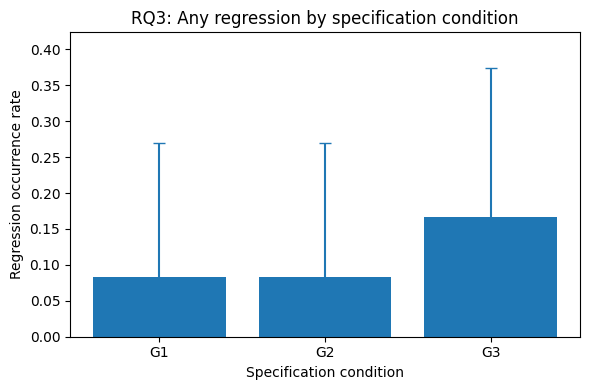

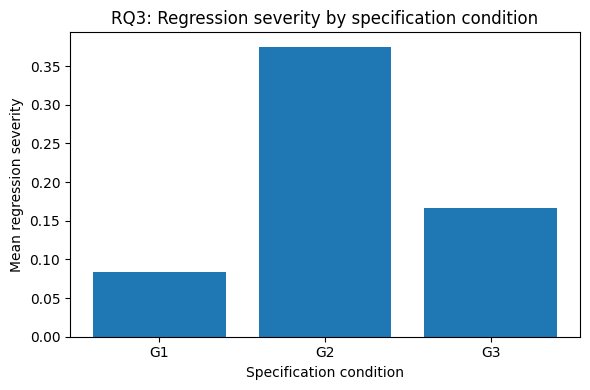

Task,A,B
specification,,
G1,0.00,0.166667
G2,0.00,0.750000
G3,0.25,0.083333


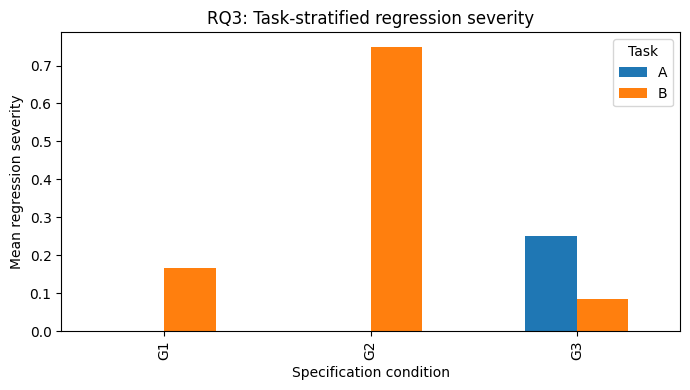

In [13]:
# ============================================================
# 9. Visualizations
# ============================================================

# Plot 1: occurrence rate by specification
plot_df = group_summary.copy()

plt.figure(figsize=(6, 4))
x = np.arange(len(plot_df))
y = plot_df["regression_occurrence_rate"].values
yerr = np.vstack([
    y - plot_df["occurrence_rate_ci_low"].values,
    plot_df["occurrence_rate_ci_high"].values - y
])
plt.bar(x, y)
plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=4)
plt.xticks(x, plot_df["specification"])
plt.ylabel("Regression occurrence rate")
plt.xlabel("Specification condition")
plt.title("RQ3: Any regression by specification condition")
plt.ylim(0, max(0.3, np.nanmax(plot_df["occurrence_rate_ci_high"]) + 0.05))
plt.tight_layout()
plt.savefig(OUT_DIR / "rq3_regression_occurrence_by_spec.png", dpi=300)
plt.show()

# Plot 2: mean severity by specification
plt.figure(figsize=(6, 4))
plt.bar(x, plot_df["regression_severity_mean"])
plt.xticks(x, plot_df["specification"])
plt.ylabel("Mean regression severity")
plt.xlabel("Specification condition")
plt.title("RQ3: Regression severity by specification condition")
plt.tight_layout()
plt.savefig(OUT_DIR / "rq3_regression_severity_by_spec.png", dpi=300)
plt.show()

# Plot 3: task-stratified severity
task_plot = task_group_summary.pivot(index="specification", columns="Task", values="regression_severity_mean")
display(task_plot)

task_plot.plot(kind="bar", figsize=(7, 4))
plt.ylabel("Mean regression severity")
plt.xlabel("Specification condition")
plt.title("RQ3: Task-stratified regression severity")
plt.tight_layout()
plt.savefig(OUT_DIR / "rq3_task_stratified_severity.png", dpi=300)
plt.show()

In [14]:
# ============================================================
# 10b. Compact covariate sensitivity summary
# ============================================================

def extract_ratio(table, contains, ratio_col):
    row = table.loc[table["term"].str.contains(contains, regex=False)]
    if row.empty:
        return np.nan
    return float(row.iloc[0][ratio_col])

print("Covariate sensitivity summary:")
print(
    f"- Questionnaire linkage: "
    f"{baseline_complete.shape[0]}/{len(rq3)} participants; "
    f"all {int(rq3['regression_occurrence'].sum())} regression events retained."
)

for label, contains in [("G2 vs G1", "[T.G2]"), ("G3 vs G1", "[T.G3]")]:
    primary_term = [
        t for t in logit_model.params.index
        if contains in t
    ][0]
    adjusted_term = [
        t for t in baseline_adjusted_model.params.index
        if contains in t
    ][0]
    print(
        f"- {label}: primary OR={np.exp(logit_model.params[primary_term]):.2f}; "
        f"Q2/Q4-adjusted OR={np.exp(baseline_adjusted_model.params[adjusted_term]):.2f}."
    )

alignment_term = alignment_logit_table.loc[
    alignment_logit_table["term"].str.contains("phase2_alignment_score"),
    "penalized_OR",
]
if not alignment_term.empty:
    print(
        "- G2/G3 exploratory alignment model: "
        f"one-SD alignment OR={alignment_term.iloc[0]:.2f} "
        "(L2-penalized; no confirmatory CI/p-value)."
    )


Covariate sensitivity summary:
- Questionnaire linkage: 65/72 participants; all 8 regression events retained.
- G2 vs G1: primary OR=1.00; Q2/Q4-adjusted OR=0.96.
- G3 vs G1: primary OR=2.22; Q2/Q4-adjusted OR=2.38.
- G2/G3 exploratory alignment model: one-SD alignment OR=1.44 (L2-penalized; no confirmatory CI/p-value).


In [15]:
# ============================================================
# 10. Auto-generate compact narrative summary
# ============================================================

def pct(x):
    return f"{100*x:.1f}%"

print("RQ3 descriptive summary:")
for _, row in group_summary.iterrows():
    print(
        f"- {row['specification']}: "
        f"{int(row['regressions_any_n'])}/{int(row['n'])} participants had any regression "
        f"({pct(row['regression_occurrence_rate'])}); "
        f"mean severity={row['regression_severity_mean']:.2f}; "
        f"mean regression rate={pct(row['regression_rate_mean'])}."
    )

print("\nAdjusted logistic ORs using profile-likelihood CIs:")
for _, row in profile_or.iterrows():
    if row["term"] == "Intercept":
        continue
    print(
        f"- {row['term']}: OR={row['OR']:.2f}, "
        f"95% profile CI [{row['OR_ci_low_profile']:.2f}, {row['OR_ci_high_profile']:.2f}]"
    )

RQ3 descriptive summary:
- G1: 2/24 participants had any regression (8.3%); mean severity=0.08; mean regression rate=0.6%.
- G2: 2/24 participants had any regression (8.3%); mean severity=0.38; mean regression rate=2.4%.
- G3: 4/24 participants had any regression (16.7%); mean severity=0.17; mean regression rate=0.7%.

Adjusted logistic ORs using profile-likelihood CIs:
- C(specification, Treatment(reference="G1"))[T.G2]: OR=1.00, 95% profile CI [0.11, 8.99]
- C(specification, Treatment(reference="G1"))[T.G3]: OR=2.22, 95% profile CI [0.39, 17.35]
- C(Task)[T.B]: OR=1.79, 95% profile CI [0.40, 9.42]


,specification,predicted_probability,predicted_probability_pct
0,G1,0.083333,8.333333
1,G2,0.083333,8.333333
2,G3,0.166667,16.666667


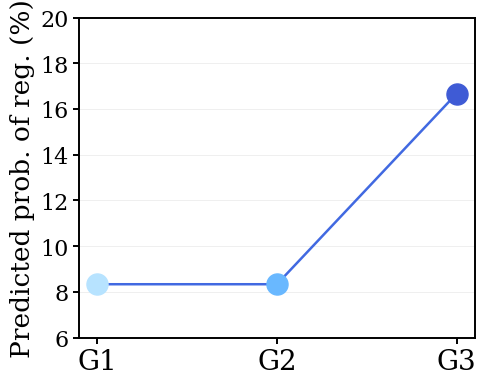

,specification,n,regressions_any_n,regression_occurrence_pct,regression_severity_mean,regression_rate_mean
0,G1,24,2,8.333333,0.083333,0.005809
1,G2,24,2,8.333333,0.375000,0.023810
2,G3,24,4,16.666667,0.166667,0.007031


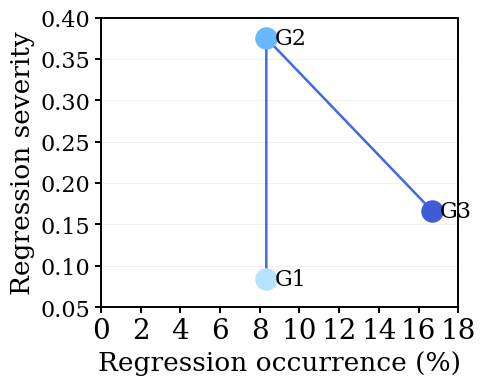

In [16]:
# ============================================================
# RQ3 publication-style figures matching shared examples
# Generates:
# 1. RQ3_predicted_probability_combined.pdf/png
# 2. RQ3_occurrence_severity_final.pdf/png
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Shared styling
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 18,
    "axes.labelsize": 19,
    "xtick.labelsize": 20,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.4,
    "xtick.major.width": 1.4,
    "ytick.major.width": 1.4,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
})

line_color = "royalblue"
marker_colors = {
    "G1": "#b7e3ff",
    "G2": "#69b8ff",
    "G3": "#3f5bd5",
}

group_order = ["G1", "G2", "G3"]

# ------------------------------------------------------------
# Prepare RQ3 dataframe
# ------------------------------------------------------------

rq3_plot = rq3.copy()

rq3_plot["specification"] = pd.Categorical(
    rq3_plot["specification"],
    categories=group_order,
    ordered=True
)

rq3_plot["Task"] = pd.Categorical(rq3_plot["Task"])


# ============================================================
# Figure 1: Predicted probability of regression
# Similar to shared RQ3_predicted_probability_combined.pdf
# ============================================================

pred_rows = []

for group in group_order:
    pred_data = rq3_plot.copy()
    pred_data["specification"] = group

    pred_prob = logit_model.predict(pred_data).mean()

    pred_rows.append({
        "specification": group,
        "predicted_probability": pred_prob,
        "predicted_probability_pct": pred_prob * 100
    })

pred_prob_df = pd.DataFrame(pred_rows)

display(pred_prob_df)

pred_prob_df.to_csv(
    OUT_DIR / "rq3_predicted_probability_by_group.csv",
    index=False
)

x = np.arange(len(group_order))
y = pred_prob_df["predicted_probability_pct"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.2))

# Connecting line
ax.plot(
    x,
    y,
    color=line_color,
    linewidth=1.8,
    zorder=1
)

# Large group markers
for i, row in pred_prob_df.iterrows():
    group = row["specification"]
    ax.scatter(
        i,
        row["predicted_probability_pct"],
        s=230,
        color=marker_colors[group],
        edgecolor=marker_colors[group],
        zorder=2
    )

ax.set_xticks(x)
ax.set_xticklabels(group_order)

ax.set_ylabel("Predicted prob. of reg. (%)")

# Match the shared figure style/range
ax.set_ylim(6, 20)
ax.set_yticks(np.arange(6, 21, 2))

ax.grid(axis="y", linestyle="-", linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "RQ3_predicted_probability_combined.pdf",
    bbox_inches="tight"
)
fig.savefig(
    FIG_DIR / "RQ3_predicted_probability_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# Figure 2: Regression occurrence vs severity
# Similar to shared RQ3_occurrence_severity_final.pdf
# ============================================================

profile_df = group_summary.copy()

profile_df["specification"] = pd.Categorical(
    profile_df["specification"],
    categories=group_order,
    ordered=True
)

profile_df = profile_df.sort_values("specification").reset_index(drop=True)

profile_df["regression_occurrence_pct"] = (
    profile_df["regression_occurrence_rate"] * 100
)

display(profile_df[[
    "specification",
    "n",
    "regressions_any_n",
    "regression_occurrence_pct",
    "regression_severity_mean",
    "regression_rate_mean"
]])

profile_df.to_csv(
    OUT_DIR / "rq3_occurrence_severity_profile.csv",
    index=False
)

x2 = profile_df["regression_occurrence_pct"].to_numpy()
y2 = profile_df["regression_severity_mean"].to_numpy()

fig, ax = plt.subplots(figsize=(5.2, 4.2))

# Connecting line through G1 -> G2 -> G3
ax.plot(
    x2,
    y2,
    color=line_color,
    linewidth=1.8,
    zorder=1
)

# Large group markers and labels
for _, row in profile_df.iterrows():
    group = row["specification"]

    ax.scatter(
        row["regression_occurrence_pct"],
        row["regression_severity_mean"],
        s=230,
        color=marker_colors[group],
        edgecolor=marker_colors[group],
        zorder=2
    )

    ax.annotate(
        group,
        (
            row["regression_occurrence_pct"],
            row["regression_severity_mean"]
        ),
        textcoords="offset points",
        xytext=(6, 0),
        ha="left",
        va="center",
        fontsize=16
    )

ax.set_xlabel("Regression occurrence (%)")
ax.set_ylabel("Regression severity")

# Match the shared figure style/range
ax.set_xlim(0, 18)
ax.set_xticks(np.arange(0, 19, 2))

ax.set_ylim(0.05, 0.40)
ax.set_yticks(np.arange(0.05, 0.401, 0.05))

ax.grid(axis="y", linestyle="-", linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)

fig.tight_layout()

fig.savefig(
    FIG_DIR / "RQ3_occurrence_severity_final.pdf",
    bbox_inches="tight"
)
fig.savefig(
    FIG_DIR / "RQ3_occurrence_severity_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()